In [7]:
import sys
import os

# 주피터 노트북 환경에서 __file__이 없으므로, 현재 워킹 디렉토리 기준으로 설정
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Load data and create features

In [13]:
from data_scraping.common.data_loader import load_movie_data, load_ratings_data

movie_data = load_movie_data()
ratings_data = load_ratings_data()

In [14]:
import pandas as pd

with pd.option_context('display.max_columns', None):
    display(ratings_data.sample(3))
    display(movie_data.sample(3))

,user_id,movie_id,rating,timestamp,time
15405682,98891,6790,4.5,1112748307,2005-04-06 00:45:07
24333327,156429,4020,3.0,1466193169,2016-06-17 19:52:49
15876624,101906,441,4.5,1287171371,2010-10-15 19:36:11


,movie_id,title,genres,imdb_id,tmdb_id,adult,backdrop_path,id,title_tmdb,original_title,overview,poster_path,media_type,original_language,genre_ids,popularity,release_date,video,vote_average,vote_count,genres_tmdb,language,total_title
72245,34767,My Date with Drew (2004),Comedy Documentary Romance,tt0378407,25975.0,False,/76G299sPITuIgAwCWM71KTop3Qc.jpg,25975,My Date with Drew,My Date with Drew,,/19ChghJMN72BG9mQeDK0D209whF.jpg,movie,en,[99],1.6145,2005-08-05,False,5.900,61.0,다큐멘터리,영어,My Date with Drew
6829,79525,Human Desire (1954),Drama Film-Noir,tt0047101,21564.0,False,/yqfeWVhhqrI8w3wACVGEeudeQv9.jpg,21564,인간의 욕망,Human Desire,한국전에서 돌아온 기관사 제프 워렌은 칼 버클리가 아내 비키의 연인 오웬을 죽이는 ...,/jENxUySE0H3XUUIP1mitESyhjEK.jpg,movie,en,"[80, 18, 10749]",2.6357,1954-08-05,False,6.736,138.0,범죄 드라마 로맨스,영어,인간의 욕망 (Human Desire)
41871,204766,Journey on the Plain (1995),Drama,tt0113491,47053.0,False,/nLSWM9Eszh3aFxVzdr61LDCwHSB.jpg,47053,Utazás az Alföldön,Utazás az Alföldön,,/rOBxj6cv9J2Y2a0PvoPu8aYVcT1.jpg,movie,hu,[18],0.9416,1995-01-01,False,5.900,8.0,드라마,헝가리어,Utazás az Alföldön


In [15]:
# 데이터셋 기본 정보 확인
print("=" * 60)
print("데이터셋 기본 정보")
print("=" * 60)
print(f"전체 영화 수: {movie_data.shape[0]:,}")
print(f"전체 평점 수: {ratings_data.shape[0]:,}")
print(f"전체 사용자 수: {ratings_data['user_id'].nunique():,}")
print(f"평점 범위: {ratings_data['rating'].min()} ~ {ratings_data['rating'].max()}")
print(f"평균 평점: {ratings_data['rating'].mean():.2f}")

데이터셋 기본 정보
전체 영화 수: 79,093
전체 평점 수: 31,242,048
전체 사용자 수: 200,945
평점 범위: 0.5 ~ 5.0
평균 평점: 3.53


In [16]:
# 활성 사용자 필터링 (최소 50개 이상 평점을 남긴 사용자만)
MIN_RATINGS = 50
user_rating_counts = ratings_data['user_id'].value_counts()
active_users = user_rating_counts[user_rating_counts >= MIN_RATINGS].index

# 인기 영화 필터링 (최소 20개 이상 평점을 받은 영화만)
MIN_MOVIE_RATINGS = 20
movie_rating_counts = ratings_data['movie_id'].value_counts()
popular_movies = movie_rating_counts[movie_rating_counts >= MIN_MOVIE_RATINGS].index

# 필터링된 데이터
filtered_ratings = ratings_data[
    (ratings_data['user_id'].isin(active_users)) & 
    (ratings_data['movie_id'].isin(popular_movies))
].copy()

print("=" * 60)
print("필터링 후 데이터셋")
print("=" * 60)
print(f"활성 사용자 수: {filtered_ratings['user_id'].nunique():,}")
print(f"인기 영화 수: {filtered_ratings['movie_id'].nunique():,}")
print(f"필터링된 평점 수: {filtered_ratings.shape[0]:,}")
print(f"데이터 감소율: {(1 - filtered_ratings.shape[0]/ratings_data.shape[0])*100:.2f}%")

필터링 후 데이터셋
활성 사용자 수: 126,973
인기 영화 수: 21,891
필터링된 평점 수: 28,675,455
데이터 감소율: 8.22%


In [17]:
# 사용자별 통계 특징 추출
user_stats = filtered_ratings.groupby('user_id').agg({
    'rating': ['mean', 'std', 'count'],
}).round(3)

user_stats.columns = ['avg_rating', 'std_rating', 'num_ratings']
user_stats = user_stats.reset_index()

# std가 NaN인 경우 0으로 처리 (평점이 모두 동일한 경우)
user_stats['std_rating'] = user_stats['std_rating'].fillna(0)

print("사용자 통계 특징:")
user_stats.describe()

사용자 통계 특징:


,avg_rating,std_rating,num_ratings
count,126973.000000,126973.000000,126973.000000
mean,3.672481,0.908116,225.838997
std,0.463535,0.250888,300.704706
min,0.507000,0.000000,10.000000
25%,3.392000,0.736000,77.000000
50%,3.691000,0.889000,127.000000
75%,3.982000,1.058000,249.000000
max,5.000000,2.270000,14935.000000


In [18]:
user_stats.sample(3)

,user_id,avg_rating,std_rating,num_ratings
65784,193739,3.651,0.801,335
99986,61535,3.193,0.766,57
82938,37294,3.818,1.056,88


In [19]:
# 더 빠른 버전 (대용량 데이터용)
import numpy as np

ratings_with_genres = filtered_ratings.merge(
    movie_data[['movie_id', 'genres']], 
    on='movie_id', 
    how='left'
)

# 장르를 분리하고 explode
ratings_with_genres['genres_list'] = ratings_with_genres['genres'].str.split()
genre_ratings_df = ratings_with_genres[['user_id', 'rating', 'genres_list']].copy()
genre_ratings_df = genre_ratings_df.explode('genres_list').dropna(subset=['genres_list'])
genre_ratings_df = genre_ratings_df[genre_ratings_df['genres_list'] != '']

# pivot_table 사용
user_genre_prefs = genre_ratings_df.pivot_table(
    index='user_id',
    columns='genres_list',
    values='rating',
    aggfunc='mean'
)

In [20]:
# 방법 1: 전체 데이터의 평균으로 채우기 (중립적)
# global_mean = user_genre_prefs.mean().mean()
# user_genre_prefs = user_genre_prefs.fillna(global_mean)

# 방법 2: 0으로 채우기 (관심 없음 표현)
user_genre_prefs = user_genre_prefs.fillna(0)

# 방법 3: 각 장르의 전체 평균으로 채우기
# genre_means = user_genre_prefs.mean(axis=0)
# user_genre_prefs = user_genre_prefs.fillna(genre_means)

print(f"\n추출된 장르 수: {user_genre_prefs.shape[1]}")
print(f"장르 목록: {sorted(user_genre_prefs.columns.tolist())}")


추출된 장르 수: 19
장르 목록: ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


In [21]:
user_genre_prefs.sample(3)

genres_list,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
user_id,,,,,,,,,,,,,,,,,,,
90522,4.328125,4.065217,4.000000,4.000000,3.931818,4.291667,0.0,4.058824,4.076923,4.333333,4.214286,4.500000,3.5,4.166667,3.761905,4.500000,4.289474,4.175000,4.75
60510,3.722222,4.090909,4.192308,4.166667,4.017241,4.500000,0.0,3.960784,4.250000,0.000000,3.833333,4.176471,4.1,3.428571,4.072917,3.700000,3.750000,4.000000,0.00
38653,3.565217,3.733333,4.500000,4.500000,3.837838,3.964286,4.5,3.848485,4.142857,4.500000,3.666667,4.333333,4.6,3.692308,4.181818,3.214286,3.787879,4.666667,4.00


In [22]:
# 모든 특징을 결합
user_features = user_stats.merge(
    user_genre_prefs,
    left_on='user_id',
    right_index=True,
    how='inner'
)

print("=" * 60)
print("최종 사용자 특징")
print("=" * 60)
print(f"사용자 수: {user_features.shape[0]:,}")
print(f"특징 수: {user_features.shape[1] - 1}")  # user_id 제외
print(f"\n특징 목록:")
print(f"- 통계 특징: avg_rating, std_rating, num_ratings")
print(f"- 장르 특징: {user_features.shape[1] - 4}개")

user_features.head()

최종 사용자 특징
사용자 수: 126,973
특징 수: 22

특징 목록:
- 통계 특징: avg_rating, std_rating, num_ratings
- 장르 특징: 19개


,user_id,avg_rating,std_rating,num_ratings,Action,Adventure,Animation,Children,Comedy,Crime,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,3.511,1.539,137,4.105263,3.470588,0.000000,3.500,3.300000,3.875000,...,5.00,3.666667,0.00000,0.000000,3.555556,3.285714,3.941176,3.500000,3.238095,3.500000
1,10,2.787,0.825,658,2.828446,2.858696,2.891304,2.800,2.649457,2.913934,...,3.50,2.754545,3.09322,3.368421,2.992424,2.634921,2.809249,2.737542,2.870370,2.500000
2,100,3.514,0.927,247,3.213333,3.377907,3.230769,3.375,3.543210,3.680556,...,4.25,3.750000,3.25000,3.450000,4.000000,3.287500,3.336735,3.609375,3.423077,5.000000
3,10000,3.619,0.776,160,3.660000,3.676471,0.000000,3.000,3.648649,3.416667,...,3.00,3.000000,0.00000,0.000000,3.333333,3.696203,3.666667,3.357143,3.818182,3.666667
4,100000,2.719,1.060,194,2.437500,2.722222,2.965517,2.900,2.508929,3.121622,...,3.50,1.100000,2.97619,2.333333,3.090909,2.725000,2.210526,2.619048,3.250000,2.333333


In [27]:
import pandas as pd

# Save user_features
# user_features.to_parquet('user_features.parquet')

# Clustering : KMeans

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.sparse import csr_matrix
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

In [5]:
import pandas as pd

# To load user_features in a future session or different notebook:
user_features = pd.read_parquet('user_features.parquet')

In [6]:
# 클러스터링을 위한 특징 준비
X = user_features.drop('user_id', axis=1).values

# 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"특징 행렬 크기: {X_scaled.shape}")
print(f"평균: {X_scaled.mean():.4f}")
print(f"표준편차: {X_scaled.std():.4f}")

특징 행렬 크기: (126973, 22)
평균: -0.0000
표준편차: 1.0000


In [ ]:
# Elbow Method로 최적 클러스터 수 찾기
inertias = [] # 각 K 값에 대한 KMeans 모델의 inertia(군집 내 분산)를 저장할 리스트
silhouette_scores = []
K_range = range(2, 11)

print("최적 클러스터 수 탐색 중...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    print(f"K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={silhouette_scores[-1]:.4f}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Elbow curve
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('클러스터 수 (K)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette score
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('클러스터 수 (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
import time
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans
import numpy as np

# 최종 클러스터링 (K=5로 설정, 필요시 위 결과를 보고 조정)
N_CLUSTERS = 3

kmeans_final = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)

start_time_kmeans = time.time()
user_features['cluster'] = kmeans_final.fit_predict(X_scaled)
end_time_kmeans = time.time()
kmeans_time = end_time_kmeans - start_time_kmeans

# 평가 지표
# Silhouette Score 계산 시간 단축을 위해 샘플링 적용
# 데이터셋이 매우 클 경우, 전체 데이터에 대한 실루엣 스코어 계산은 시간이 오래 걸릴 수 있습니다.
# 여기서는 전체 데이터의 10%를 샘플링하여 계산합니다. 필요에 따라 SAMPLE_FRACTION을 조정하세요.
SAMPLE_FRACTION = 0.1 # 전체 데이터의 10% 샘플링

if len(X_scaled) > 0 and SAMPLE_FRACTION > 0:
    # 샘플링할 인덱스 선택
    num_samples = int(len(X_scaled) * SAMPLE_FRACTION)
    if num_samples == 0: # 최소 1개 샘플은 있어야 함
        num_samples = 1
    
    # X_scaled가 numpy 배열인 경우
    if isinstance(X_scaled, np.ndarray):
        sample_indices = np.random.choice(len(X_scaled), num_samples, replace=False)
        X_scaled_sample = X_scaled[sample_indices]
        cluster_labels_sample = user_features['cluster'].iloc[sample_indices]
    # X_scaled가 pandas DataFrame인 경우
    else: 
        X_scaled_sample = X_scaled.sample(n=num_samples, random_state=42)
        cluster_labels_sample = user_features['cluster'].loc[X_scaled_sample.index]

    start_time_silhouette = time.time()
    silhouette = silhouette_score(X_scaled_sample, cluster_labels_sample)
    end_time_silhouette = time.time()
    silhouette_time = end_time_silhouette - start_time_silhouette
    print(f"Silhouette Score calculated on a {SAMPLE_FRACTION*100:.0f}% sample ({num_samples} samples).")
else:
    # 샘플링이 불가능하거나 필요 없는 경우 전체 데이터 사용
    start_time_silhouette = time.time()
    silhouette = silhouette_score(X_scaled, user_features['cluster'])
    end_time_silhouette = time.time()
    silhouette_time = end_time_silhouette - start_time_silhouette
    print("Silhouette Score calculated on full dataset (sampling not applied).")


start_time_davies = time.time()
davies_bouldin = davies_bouldin_score(X_scaled, user_features['cluster'])
end_time_davies = time.time()
davies_bouldin_time = end_time_davies - start_time_davies

print("=" * 60)
print(f"최종 클러스터링 결과 (K={N_CLUSTERS})")
print("=" * 60)
print(f"KMeans 실행 시간: {kmeans_time:.4f} 초")
print(f"Silhouette Score 계산 시간: {silhouette_time:.4f} 초")
print(f"Davies-Bouldin Index 계산 시간: {davies_bouldin_time:.4f} 초")
print(f"Silhouette Score: {silhouette:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin:.4f}")
print(f"\n클러스터별 사용자 수:")
print(user_features['cluster'].value_counts().sort_index())

Silhouette Score calculated on a 10% sample (12697 samples).
최종 클러스터링 결과 (K=3)
KMeans 실행 시간: 1.3893 초
Silhouette Score 계산 시간: 1.0931 초
Davies-Bouldin Index 계산 시간: 0.0189 초
Silhouette Score: 0.1511
Davies-Bouldin Index: 1.8711

클러스터별 사용자 수:
cluster
0    61927
1    24604
2    40442
Name: count, dtype: int64


In [11]:
import time
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

# 계층적 클러스터링 (Agglomerative) 대신 MiniBatchKMeans 사용
# AgglomerativeClustering은 대규모 데이터셋에서 메모리 문제(커널 죽음)를 일으킬 수 있습니다.
# MiniBatchKMeans는 대용량 데이터셋에 적합한 대안입니다.
print("\n" + "=" * 60)
print("MiniBatchKMeans 클러스터링 (대규모 데이터셋용)")
print("=" * 60)

n_clusters_mbkm = 3
# batch_size는 데이터셋 크기에 따라 조정할 수 있습니다. 기본값은 256입니다.
# n_init은 KMeans와 유사하게 여러 번 초기화하여 최적의 결과를 찾습니다.
mbkm_clustering = MiniBatchKMeans(
    n_clusters=n_clusters_mbkm,
    random_state=42,  # 재현성을 위해 random_state 설정
    n_init=10  # 여러 번 초기화하여 더 나은 결과 탐색
)

start_time_mbkm = time.time() # 시작 시간 기록
mbkm_labels = mbkm_clustering.fit_predict(X_scaled)
end_time_mbkm = time.time() # 종료 시간 기록

print(f"클러스터 개수: {n_clusters_mbkm}")
print(f"완료 시간: {end_time_mbkm - start_time_mbkm:.2f} 초") # 완료 시간 출력

# 실루엣 스코어 계산 개선 (대규모 데이터셋의 경우 샘플링 사용)
start_time_sil = time.time()
if X_scaled.shape[0] > 10000:  # 데이터셋이 클 경우 샘플링
    sample_size = 10000
    # 무작위 샘플링을 위해 인덱스를 생성하고 섞습니다.
    indices = np.random.choice(X_scaled.shape[0], sample_size, replace=False)
    X_scaled_sample = X_scaled[indices]
    mbkm_labels_sample = mbkm_labels[indices]
    sil_score_mbkm = silhouette_score(X_scaled_sample, mbkm_labels_sample)
    print(f"Silhouette Score (샘플 {sample_size}개): {sil_score_mbkm:.4f}")
else:
    sil_score_mbkm = silhouette_score(X_scaled, mbkm_labels)
    print(f"Silhouette Score: {sil_score_mbkm:.4f}")
end_time_sil = time.time()
print(f"Silhouette Score 계산 시간: {end_time_sil - start_time_sil:.2f} 초")

db_score_mbkm = davies_bouldin_score(X_scaled, mbkm_labels)
print(f"Davies-Bouldin Score: {db_score_mbkm:.4f}")

# 클러스터별 크기
unique, counts = np.unique(mbkm_labels, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f"클러스터 {cluster_id}: {count:,}명")


MiniBatchKMeans 클러스터링 (대규모 데이터셋용)
클러스터 개수: 3
완료 시간: 0.21 초
Silhouette Score (샘플 10000개): 0.1422
Silhouette Score 계산 시간: 0.71 초
Davies-Bouldin Score: 1.9346
클러스터 0: 37,291명
클러스터 1: 29,115명
클러스터 2: 60,567명


In [6]:
# 클러스터별 프로파일 생성
cluster_profiles = user_features.groupby('cluster').agg({
    'avg_rating': 'mean',
    'std_rating': 'mean',
    'num_ratings': 'mean'
}).round(3)

print("=" * 60)
print("클러스터별 통계 프로파일")
print("=" * 60)
print(cluster_profiles)

# 클러스터별 장르 선호도
genre_columns = [col for col in user_features.columns if col not in ['user_id', 'avg_rating', 'std_rating', 'num_ratings', 'cluster']]
cluster_genre_prefs = user_features.groupby('cluster')[genre_columns].mean()

print("\n" + "=" * 60)
print("클러스터별 장르 선호도 (상위 5개)")
print("=" * 60)
for cluster_id in range(N_CLUSTERS):
    top_genres = cluster_genre_prefs.loc[cluster_id].sort_values(ascending=False).head(10)
    print(f"\nCluster {cluster_id}:")
    for genre, score in top_genres.items():
        print(f"  {genre}: {score:.3f}")

클러스터별 통계 프로파일
         avg_rating  std_rating  num_ratings
cluster                                     
0             3.615       0.925      228.439
1             3.023       1.104      337.618
2             4.155       0.763      153.854

클러스터별 장르 선호도 (상위 5개)

Cluster 0:
  War: 3.745
  Drama: 3.736
  Crime: 3.725
  Mystery: 3.663
  Thriller: 3.589
  Romance: 3.586
  Adventure: 3.539
  Fantasy: 3.520
  Comedy: 3.514
  Action: 3.504

Cluster 1:
  Drama: 3.189
  Crime: 3.137
  War: 3.109
  Mystery: 3.080
  Romance: 2.989
  Thriller: 2.978
  Comedy: 2.904
  Adventure: 2.878
  Fantasy: 2.850
  Action: 2.848

Cluster 2:
  Crime: 4.237
  Drama: 4.222
  Mystery: 4.203
  War: 4.182
  Thriller: 4.145
  Adventure: 4.125
  Romance: 4.121
  Fantasy: 4.114
  Action: 4.105
  Sci-Fi: 4.088


인기있는 장르가 주로 보이네 -> 클러스터 상위 top4가 같음
- Drama
- Crime
- Mystery
- War

클러스터 개수를 늘려봐야 하나?

PCA 설명된 분산: 59.55%


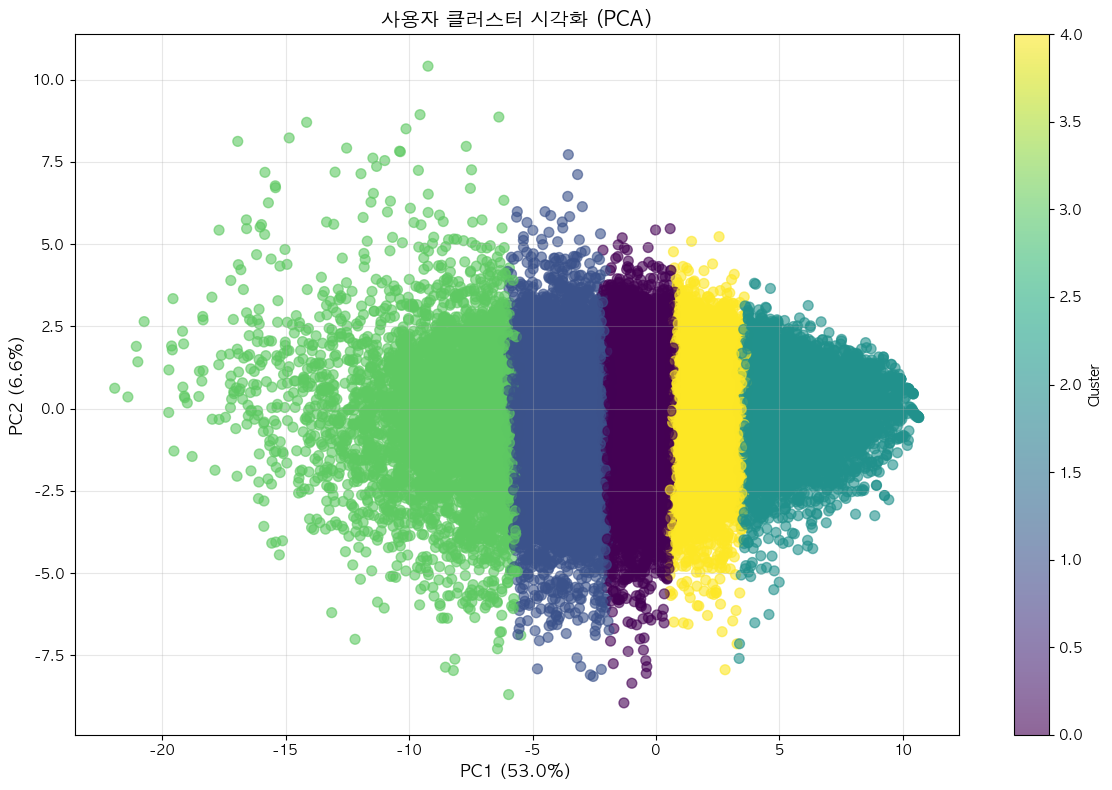

In [30]:
# PCA로 차원 축소하여 시각화
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA 설명된 분산: {pca.explained_variance_ratio_.sum()*100:.2f}%")

# 시각화
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    X_pca[:, 0], 
    X_pca[:, 1], 
    c=user_features['cluster'], 
    cmap='viridis', 
    alpha=0.6,
    s=50
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.title('사용자 클러스터 시각화 (PCA)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

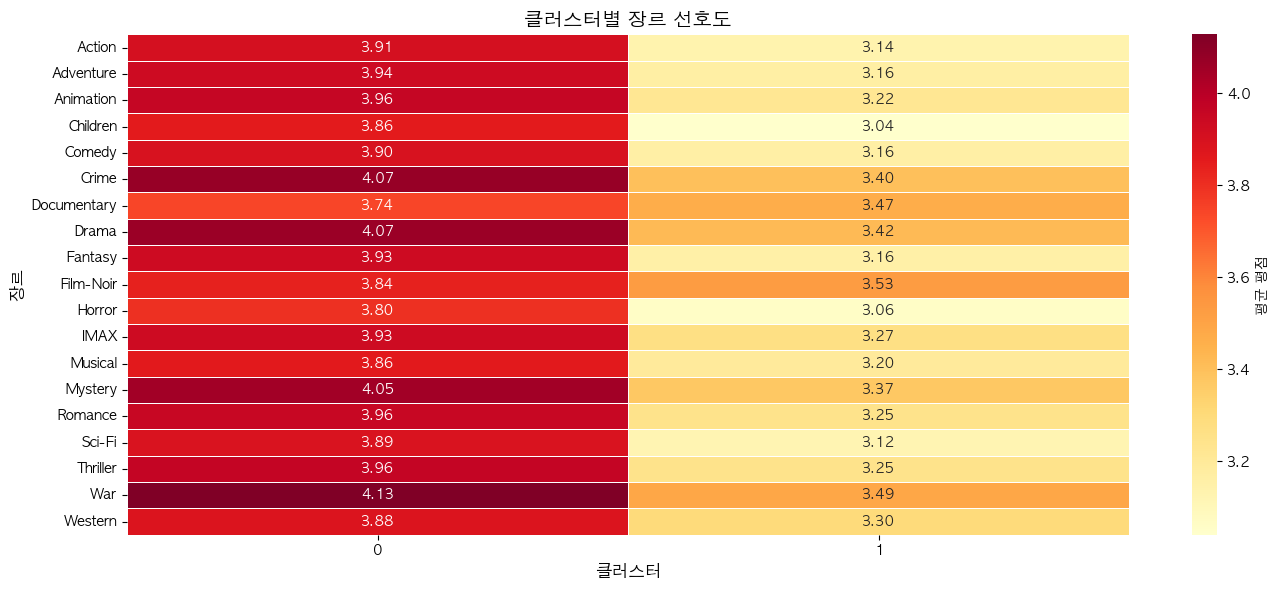

In [26]:
# 클러스터별 장르 선호도 히트맵
plt.figure(figsize=(14, 6))
sns.heatmap(
    cluster_genre_prefs.T, 
    cmap='YlOrRd', 
    annot=True, 
    fmt='.2f',
    cbar_kws={'label': '평균 평점'},
    linewidths=0.5
)
plt.title('클러스터별 장르 선호도', fontsize=14, fontweight='bold')
plt.xlabel('클러스터', fontsize=12)
plt.ylabel('장르', fontsize=12)
plt.tight_layout()
plt.show()

In [27]:
# 클러스터 정보를 포함한 사용자 데이터 저장
# import os
# output_path = os.path.join(project_root, 'data', 'processed', 'user_clusters.csv')
# os.makedirs(os.path.dirname(output_path), exist_ok=True)

# user_features[['user_id', 'cluster', 'avg_rating', 'std_rating', 'num_ratings']].to_csv(
#     output_path, 
#     index=False
# )

# print(f"클러스터 결과 저장 완료: {output_path}")
# print(f"총 {len(user_features)} 명의 사용자 정보 저장됨")

# Clusterin : DBSCAN

In [9]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# To load user_features in a future session or different notebook:
user_features = pd.read_parquet('user_features.parquet')

# 클러스터링을 위한 특징 준비
X = user_features.drop('user_id', axis=1).values

# 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"특징 행렬 크기: {X_scaled.shape}")
print(f"평균: {X_scaled.mean():.4f}")
print(f"표준편차: {X_scaled.std():.4f}")

특징 행렬 크기: (126973, 22)
평균: -0.0000
표준편차: 1.0000


In [ ]:
from sklearn.cluster import DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

# DBSCAN 적용
# 노이즈가 많이 잡히는 경우, eps 값을 늘리거나 min_samples 값을 줄여보세요.
dbscan = DBSCAN(eps=1.0, min_samples=100, n_jobs=-1)
dbscan_labels = dbscan.fit_predict(X_scaled)

# 클러스터 개수 확인 (-1은 노이즈)
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_dbscan = list(dbscan_labels).count(-1)

print(f"클러스터 개수: {n_clusters_dbscan}")
print(f"노이즈 포인트: {n_noise_dbscan}")

# 노이즈를 제외한 데이터로 평가
if n_clusters_dbscan > 1:
    mask = dbscan_labels != -1
    if mask.sum() > 0:
        sil_score_dbscan = silhouette_score(X_scaled[mask], dbscan_labels[mask])
        db_score_dbscan = davies_bouldin_score(X_scaled[mask], dbscan_labels[mask])
        print(f"Silhouette Score: {sil_score_dbscan:.4f}")
        print(f"Davies-Bouldin Score: {db_score_dbscan:.4f}")

클러스터 개수: 3
노이즈 포인트: 119089
Silhouette Score: 0.2564
Davies-Bouldin Score: 1.0684


In [23]:
user_features['dbscan_cluster'] = dbscan_labels

# 클러스터별 프로파일 생성 (DBSCAN 결과 사용)
# DBSCAN은 노이즈를 -1로 할당하므로, -1 클러스터를 제외하고 프로파일을 생성합니다.
dbscan_cluster_profiles = user_features[user_features['dbscan_cluster'] != -1].groupby('dbscan_cluster').agg(
    avg_rating=('avg_rating', 'mean'),
    std_rating=('std_rating', 'mean'),
    num_ratings=('num_ratings', 'mean'),
    instance_count=('dbscan_cluster', 'size')  # 클러스터별 인스턴스 개수 추가
).round(3)

print("=" * 60)
print("DBSCAN 클러스터별 통계 프로파일")
print("=" * 60)
print(dbscan_cluster_profiles)

# 클러스터별 장르 선호도 (DBSCAN 결과 사용)
genre_columns = [col for col in user_features.columns if col not in ['user_id', 'avg_rating', 'std_rating', 'num_ratings', 'cluster', 'dbscan_cluster']]
dbscan_cluster_genre_prefs = user_features[user_features['dbscan_cluster'] != -1].groupby('dbscan_cluster')[genre_columns].mean()

print("\n" + "=" * 60)
print("DBSCAN 클러스터별 장르 선호도 (상위 5개)")
print("=" * 60)
for cluster_id in dbscan_cluster_genre_prefs.index:
    top_genres = dbscan_cluster_genre_prefs.loc[cluster_id].sort_values(ascending=False).head(10)
    print(f"\nCluster {cluster_id}:")
    for genre, score in top_genres.items():
        print(f"  {genre}: {score:.3f}")

DBSCAN 클러스터별 통계 프로파일
                avg_rating  std_rating  num_ratings  instance_count
dbscan_cluster                                                     
0                    3.727       0.690      451.163            6966
1                    4.019       0.577      216.470             793
2                    4.033       0.558      164.912             125

DBSCAN 클러스터별 장르 선호도 (상위 5개)

Cluster 0:
  Film-Noir: 3.955
  War: 3.883
  Documentary: 3.869
  Drama: 3.832
  Crime: 3.829
  Mystery: 3.817
  Animation: 3.785
  Western: 3.776
  Musical: 3.716
  Romance: 3.704

Cluster 1:
  War: 4.127
  Crime: 4.102
  Drama: 4.098
  Western: 4.096
  Mystery: 4.082
  Film-Noir: 4.078
  Animation: 4.037
  Thriller: 4.009
  Romance: 4.008
  Musical: 3.983

Cluster 2:
  War: 4.181
  Crime: 4.101
  Drama: 4.099
  Animation: 4.087
  Mystery: 4.080
  IMAX: 4.045
  Fantasy: 4.024
  Western: 4.024
  Children: 4.022
  Adventure: 4.020


## 이거 기반으로 GPT에게 시켜서 프로파일 생성한 결과

아래는 제공하신 상위 10개 장르 평균 평점을 기반으로, **각 클러스터의 이용자 취향을 텍스트 프로파일로 요약한 결과**입니다.
목표는 비즈니스 문서 수준의 간결한 프로파일링이며, 클러스터별 콘텐츠 소비 성향을 기술하는 방식입니다.

---

Cluster 0 프로파일

이 클러스터는 **고전 기반의 사실적·서사적 콘텐츠**에 높은 반응을 보인다. Film-Noir, War, Documentary, Drama, Crime, Mystery 장르가 상위권을 차지하고 있으며, 이는 **현실 기반 스토리, 인간 내면 갈등, 수사·범죄 중심의 정통 내러티브**에 대한 선호가 뚜렷함을 의미한다.
Western, Musical, Romance 등 상대적으로 클래식한 장르에도 고른 호감도를 보여, **전통적 장르 전반에 대한 관용적 취향을 가진 안정적 시청 패턴**으로 해석된다.

핵심 키워드: 사실적 내러티브, 수사/범죄, 인간 심리, 고전 장르 선호, 안정적 취향

---

Cluster 1 프로파일

이 클러스터는 **고전 장르 + 긴장감 있는 서사 구조**에 대한 선호가 매우 강하다. War, Crime, Drama, Western, Mystery, Film-Noir 등이 높은 점수를 보이며, Thriller 또한 상위권에 포함된다.
이는 **전통적 장르를 기반으로 하되, 서스펜스·갈등·역동적 전개가 강한 작품군**을 선호하는 경향을 의미한다. Romance·Musical에서의 비교적 높은 점수는 **감정선이 뚜렷한 서사에도 호의적**임을 시사한다.

핵심 키워드: 클래식 장르 중심, 서스펜스 선호, 강한 갈등 구조, 스토리 주도형 시청 패턴

---

Cluster 2 프로파일

Cluster 2는 **정통 장르 + 가족/판타지/모험 콘텐츠까지 스펙트럼이 확장된 균형형 취향 그룹**이다. War, Crime, Drama와 같은 클래식 장르에서 높은 점수를 보이면서도, Animation, Fantasy, Children, Adventure, IMAX가 모두 상위권에 존재한다.
이는 **정통 드라마틱 장르와 판타지·가족·애니메이션 기반의 확장형 엔터테인먼트를 모두 소비하는 광범위 취향층**으로 해석된다. 전통적 내러티브와 시각적 스펙터클 모두에 지불 의향이 높은 그룹이다.

핵심 키워드: 균형형 취향, 가족/판타지/애니메이션 확장, 정통 드라마/범죄 선호, 시각적 스케일 중시

---

종합 요약

* **Cluster 0:** 현실 기반·정통적 서사 중심의 클래식 장르 선호
* **Cluster 1:** 클래식 장르 기반 + 서스펜스/긴장감 강화된 서사 선호
* **Cluster 2:** 전통적 장르와 판타지/애니/가족/모험 장르까지 폭넓은 균형형 취향

필요하다면 **마케팅용 페르소나 버전**, **추천 시스템 설명용 요약**, **SQL 기반 클러스터 라벨링 룰** 등으로 재정의해줄게.


# Clustering : Hierarchical Clustering

-> 데이터가 수십만건 이상이면 비효율적임.   
-> 노트북에서 실행하니까 커널 죽더라


단점
- 대규모 데이터에는 비효율적
- O(n²) ~ O(n³) 시간 복잡도
- 10만 건 이상이면 실질적으로 어렵다
- 한 번 묶인 병합은 되돌릴 수 없음 (greedy)
- 고차원 데이터에서는 거리 기반 모델의 한계 존재

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# To load user_features in a future session or different notebook:
user_features = pd.read_parquet('./user_features.parquet')

# 클러스터링을 위한 특징 준비
X = user_features.drop('user_id', axis=1).values

# 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"특징 행렬 크기: {X_scaled.shape}")
print(f"평균: {X_scaled.mean():.4f}")
print(f"표준편차: {X_scaled.std():.4f}")

특징 행렬 크기: (126973, 22)
평균: -0.0000
표준편차: 1.0000


# Clustering : GMM

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# To load user_features in a future session or different notebook:
user_features = pd.read_parquet('user_features.parquet')

# 클러스터링을 위한 특징 준비
X = user_features.drop('user_id', axis=1).values

# 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"특징 행렬 크기: {X_scaled.shape}")
print(f"평균: {X_scaled.mean():.4f}")
print(f"표준편차: {X_scaled.std():.4f}")

특징 행렬 크기: (126973, 22)
평균: -0.0000
표준편차: 1.0000


In [2]:
import time
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

n_components_gmm = 5

# 모델 학습 시간 측정 시작
start_time_model = time.time()

gmm = GaussianMixture(
    n_components=n_components_gmm,
    covariance_type='full',  # 'tied', 'diag', 'spherical' 등도 가능
    random_state=42,
    n_init=10
)
gmm_labels = gmm.fit_predict(X_scaled)

# 모델 학습 시간 측정 종료 및 출력
end_time_model = time.time()
print(f"GMM 모델 학습 시간: {end_time_model - start_time_model:.2f} 초")

print(f"컴포넌트 개수: {n_components_gmm}")
print(f"BIC Score: {gmm.bic(X_scaled):.2f}")
print(f"AIC Score: {gmm.aic(X_scaled):.2f}")

# 메트릭 계산 시간 측정 시작
start_time_metrics = time.time()

# 실루엣 스코어 계산 시간 개선: 대규모 데이터셋의 경우 샘플링 적용
# 샘플링할 데이터 포인트 수 설정 (예: 10,000개 또는 전체 데이터의 일정 비율)
n_samples_for_silhouette = min(10000, X_scaled.shape[0])

if X_scaled.shape[0] > n_samples_for_silhouette:
    # 데이터와 레이블을 함께 샘플링하여 일관성 유지
    indices = np.random.choice(X_scaled.shape[0], n_samples_for_silhouette, replace=False)
    X_scaled_sampled = X_scaled[indices]
    gmm_labels_sampled = gmm_labels[indices]
    print(f"실루엣 스코어 계산을 위해 {n_samples_for_silhouette}개의 샘플 사용")
    sil_score_gmm = silhouette_score(X_scaled_sampled, gmm_labels_sampled)
else:
    sil_score_gmm = silhouette_score(X_scaled, gmm_labels)

db_score_gmm = davies_bouldin_score(X_scaled, gmm_labels)

# 메트릭 계산 시간 측정 종료 및 출력
end_time_metrics = time.time()
print(f"메트릭 계산 시간: {end_time_metrics - start_time_metrics:.2f} 초")

print(f"Silhouette Score: {sil_score_gmm:.4f}")
print(f"Davies-Bouldin Score: {db_score_gmm:.4f}")

# 클러스터별 크기
unique, counts = np.unique(gmm_labels, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f"클러스터 {cluster_id}: {count:,}명")

GMM 모델 학습 시간: 105.95 초
컴포넌트 개수: 5
BIC Score: 3643064.60
AIC Score: 3629616.96
실루엣 스코어 계산을 위해 10000개의 샘플 사용
메트릭 계산 시간: 0.81 초
Silhouette Score: 0.0057
Davies-Bouldin Score: 3.9923
클러스터 0: 45,366명
클러스터 1: 10,757명
클러스터 2: 27,209명
클러스터 3: 14,673명
클러스터 4: 28,968명


In [4]:
gmm_proba = gmm.predict_proba(X_scaled)
print(gmm_proba[:5])

[[0.00000000e+000 1.65800517e-017 1.06547688e-026 1.00000000e+000
  3.17566443e-145]
 [0.00000000e+000 1.40775487e-021 2.25029206e-006 9.48248608e-067
  9.99997750e-001]
 [0.00000000e+000 7.61540603e-004 9.99226602e-001 2.40485819e-011
  1.18569681e-005]
 [0.00000000e+000 1.03149176e-008 6.22887282e-016 9.99999990e-001
  9.63322255e-106]
 [0.00000000e+000 3.20607528e-002 9.67938576e-001 3.71157429e-007
  3.00157631e-007]]


In [5]:
user_features['cluster'] = gmm_labels
user_features_with_cluster = user_features

In [9]:
from modeling.utils import cluster

cluster.print_cluster_profiles(user_features_with_cluster, n_components_gmm)

클러스터별 통계 프로파일
         avg_rating  std_rating  num_ratings
cluster                                     
0             3.717       0.898      111.251
1             3.878       0.822      116.172
2             3.602       0.979      215.240
3             3.621       1.106       83.804
4             3.619       0.788      527.915

클러스터별 장르 선호도 (상위 10개)

Cluster 0:
  Drama: 3.821
  Crime: 3.804
  Mystery: 3.787
  War: 3.782
  Animation: 3.736
  Romance: 3.710
  Thriller: 3.696
  Adventure: 3.689
  Fantasy: 3.676
  Action: 3.652

Cluster 1:
  War: 4.022
  Crime: 4.004
  Drama: 3.978
  Mystery: 3.964
  Thriller: 3.901
  IMAX: 3.807
  Romance: 3.804
  Action: 3.791
  Sci-Fi: 3.778
  Adventure: 3.746

Cluster 2:
  Film-Noir: 3.846
  War: 3.798
  Crime: 3.745
  Drama: 3.728
  Mystery: 3.715
  Animation: 3.599
  Thriller: 3.580
  Romance: 3.570
  Musical: 3.534
  Fantasy: 3.528

Cluster 3:
  Drama: 3.730
  Crime: 3.659
  Thriller: 3.537
  Romance: 3.533
  Comedy: 3.506
  Adventure: 3.438
  Actio

# Clustering : Spectral Clustering


## 실무에서 Spectral Clustering이 좋은 경우

다음 케이스에서 가장 강력하다:

- 클러스터 경계가 비선형
    예: 반달형으로 생긴 2개의 군집
    → KMeans는 실패, Spectral은 완벽 분리

- 데이터가 manifold 형태
    예: 고차원 embedding에서 나선형 구조

- similarity 기반 군집이 필요한 경우
유클리드 거리가 의미 없고
유사도나 그래프 연결성이 중요한 데이터

- 이미 similarity matrix가 애초에 존재하는 경우
    예:
    - 문장/문서 간 cosine similarity
    - 소셜네트워크 adjacency matrix
    - 이미지 similarity graph

## Spectral Clustering 단점

- O(n³) 고유분해 때문에 대규모 데이터에는 부적합 (보통 n=10,000 이하)
- similarity matrix가 n×n이므로 메모리 부담 큼
- 사용자가 k(클러스터 수)를 알아야 함
- hyperparameter (sigma, kNN 수) 조정 필요

In [ ]:
# 4. Spectral Clustering
print("\n" + "=" * 60)
print("스펙트럴 클러스터링")
print("=" * 60)

# 샘플 크기 제한 (전체 데이터에 적용하면 시간이 오래 걸릴 수 있음)
sample_size = min(10000, len(user_features_scaled))
sample_indices = np.random.choice(len(user_features_scaled), sample_size, replace=False)
user_features_sample = user_features_scaled[sample_indices]

n_clusters_spec = 5
spectral = SpectralClustering(
    n_clusters=n_clusters_spec,
    affinity='rbf',  # 'nearest_neighbors', 'precomputed' 등도 가능
    random_state=42,
    n_jobs=-1
)
spectral_labels = spectral.fit_predict(user_features_sample)

print(f"클러스터 개수: {n_clusters_spec}")
print(f"샘플 크기: {sample_size:,}")
sil_score_spec = silhouette_score(user_features_sample, spectral_labels)
db_score_spec = davies_bouldin_score(user_features_sample, spectral_labels)
print(f"Silhouette Score: {sil_score_spec:.4f}")
print(f"Davies-Bouldin Score: {db_score_spec:.4f}")

# 클러스터별 크기
unique, counts = np.unique(spectral_labels, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f"클러스터 {cluster_id}: {count:,}명")

# Clustering : Mean Shift

In [ ]:
# 5. Mean Shift
print("\n" + "=" * 60)
print("Mean Shift 클러스터링")
print("=" * 60)

# bandwidth 자동 추정 (샘플링하여 속도 향상)
bandwidth = estimate_bandwidth(user_features_sample, quantile=0.2, n_samples=1000)
print(f"추정된 Bandwidth: {bandwidth:.4f}")

meanshift = MeanShift(bandwidth=bandwidth, bin_seeding=True, n_jobs=-1)
meanshift_labels = meanshift.fit_predict(user_features_sample)

n_clusters_ms = len(set(meanshift_labels))
print(f"클러스터 개수: {n_clusters_ms}")

if n_clusters_ms > 1:
    sil_score_ms = silhouette_score(user_features_sample, meanshift_labels)
    db_score_ms = davies_bouldin_score(user_features_sample, meanshift_labels)
    print(f"Silhouette Score: {sil_score_ms:.4f}")
    print(f"Davies-Bouldin Score: {db_score_ms:.4f}")
    
    # 클러스터별 크기
    unique, counts = np.unique(meanshift_labels, return_counts=True)
    for cluster_id, count in zip(unique, counts):
        print(f"클러스터 {cluster_id}: {count:,}명")